In [ ]:
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_probability as tfp
tfd = tfp.distributions

from scipy.stats import norm
from scipy.stats import skewnorm
import statsmodels.api as sm

from tqdm.notebook import tqdm
import pickle
import pandas as pd
import os

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
%matplotlib inline

In [ ]:
dtype = 'float32'

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
from uncertainty import *
from utils import *

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.cluster import KMeans

## Data

In [ ]:
dataset_choice = 'Concrete' # Choose one of: 'Boston', 'Concrete', 'Wine'

In [ ]:
n_clusters = 2

In [ ]:
minority_p = 0.1
majority_p = 1 - minority_p

In [ ]:
# Load data
if dataset_choice == 'Boston':
    boston = fetch_openml(name='boston', version=1, as_frame=True)
    df = boston.frame
    target_column = 'MEDV'
elif dataset_choice == 'Concrete':
    concrete = fetch_openml(name='concrete_compressive_strength',  as_frame=True)
    df = concrete.frame
    # Compute water-to-cement ratio and add it as a new column for splitting
    df['water_cement'] = df['water'] / df['cement']
    target_column = 'strength'
elif dataset_choice == 'Wine':
    wine = fetch_openml(name='wine-quality-red', version=1, as_frame=True)
    df = wine.frame
    target_column = 'class'
else:
    raise ValueError("Dataset not recognized. Choose one of: 'Boston', 'Concrete', 'Energy', 'Airfoil', 'Wine'.")

numeric_cols = df.select_dtypes(include=['float', 'int']).columns

# Clustering features: all numeric columns except the target
clustering_features = df[[col for col in numeric_cols if col != target_column]]

print("Using dataset:", dataset_choice)
print("Numeric columns:", numeric_cols.tolist())

/usr/local/lib/python3.11/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name concrete_compressive_strength exist. Versions may be fundamentally different, returning version 7. Available versions:
- version 7, status: active
  url: https://www.openml.org/search?type=data&id=44959
- version 8, status: active
  url: https://www.openml.org/search?type=data&id=46917

  warn(warning_msg)


Using dataset: Concrete
Numeric columns: ['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age', 'strength', 'water_cement']


In [ ]:
# Cluster the data with KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(clustering_features)

# --- Determine clusters for train and test ---
if n_clusters == 2:
    # Average within-cluster distances for each cluster.
    avg_within_distance = {}
    for cl in df['cluster'].unique():
        cluster_data = df[df['cluster'] == cl][clustering_features.columns]
        cluster_centroid = cluster_data.mean(axis=0)
        # Distances from each point to the cluster centroid.
        distances_within = np.linalg.norm(cluster_data - cluster_centroid, axis=1)
        avg_within_distance[cl] = np.mean(distances_within)

    print("Within-cluster distances for each cluster:")
    for cl, avg_dist in avg_within_distance.items():
        print(f"Cluster {cl}: {avg_dist:.4f}")

    # The cluster with the larger average within-cluster distance is chosen as the train cluster.
    test_cluster = min(avg_within_distance, key=avg_within_distance.get)
    train_cluster = max(avg_within_distance, key=avg_within_distance.get)

else:
    # For n_clusters > 2 compute the global centroid of the clustering features.
    global_centroid = clustering_features.mean(axis=0)
    distances = {}
    for cl in df['cluster'].unique():
        cluster_centroid = df[df['cluster'] == cl][clustering_features.columns].mean(axis=0)
        distances[cl] = np.linalg.norm(cluster_centroid - global_centroid)
    test_cluster = max(distances, key=distances.get)
    train_cluster = None

    # Average distance from test cluster centroid to each of the other clusters.
    centroids = {}
    for cl in df['cluster'].unique():
        centroids[cl] = df[df['cluster'] == cl][clustering_features.columns].mean(axis=0)
    d_test = [np.linalg.norm(centroids[test_cluster] - centroids[cl])
              for cl in centroids if cl != test_cluster]
    avg_test_distance = np.mean(d_test)

    # Average pairwise distance among non-test cluster centroids.
    non_test_clusters = [cl for cl in centroids if cl != test_cluster]
    from itertools import combinations
    pairwise_dists = [np.linalg.norm(centroids[cl1] - centroids[cl2])
                      for cl1, cl2 in combinations(non_test_clusters, 2)]
    avg_majority_distance = np.mean(pairwise_dists)

    print("Average distance from test cluster to other clusters: {:.4f}".format(avg_majority_distance))
    print("Average pairwise distance among non-test clusters: {:.4f}".format(avg_majority_distance))

# Assign original groups based on clusters.
if n_clusters == 2:
    # Use the computed train and test clusters.
    orig_train_df = df[df['cluster'] == train_cluster].copy()
    orig_test_df = df[df['cluster'] == test_cluster].copy()
else:
    # For more than 2 clusters, all non-test clusters go to training.
    orig_train_df = df[df['cluster'] != test_cluster].copy()
    orig_test_df = df[df['cluster'] == test_cluster].copy()

# Shuffle each original group to ensure random selection.
orig_train_shuffled = orig_train_df.sample(frac=1, random_state=42)
orig_test_shuffled = orig_test_df.sample(frac=1, random_state=42)

# Split to train and test
n_train_total = len(orig_train_shuffled)
n_test_total = len(orig_test_shuffled)

n_test_minority = int(n_test_total * minority_p)
n_test_majority = int(n_test_total * majority_p)

n_train_minority = n_test_total - n_test_minority
n_train_majority = int((majority_p / minority_p) * n_train_minority)

final_test_df = pd.concat([orig_test_shuffled.iloc[0:n_test_minority],
                           orig_train_shuffled.iloc[0:n_test_majority]])
final_train_df = pd.concat([orig_test_shuffled.iloc[n_test_minority:n_test_minority+n_train_minority],
                            orig_train_shuffled.iloc[n_test_majority:n_test_majority+n_train_majority]])

# Shuffle the final training set.
final_train_df = final_train_df.sample(frac=1, random_state=42)

# Drop the cluster column as it's no longer needed.
final_train_df.drop(columns=['cluster'], inplace=True)
final_test_df.drop(columns=['cluster'], inplace=True)

# Split into features and targets
Xs = final_train_df.drop(columns=[target_column])
new_Xs = final_test_df.drop(columns=[target_column])
Ys = final_train_df[target_column]
new_Ys = final_test_df[target_column]

# Convert to numpy arrays
Xs = np.array(Xs).astype(dtype)
new_Xs = np.array(new_Xs).astype(dtype)
Ys = np.array(Ys).reshape(-1, 1).astype(dtype)
new_Ys = np.array(new_Ys).reshape(-1, 1).astype(dtype)
d = Xs.shape[1]

# Scale data using training set statistics
my, sy = np.median(Ys), Ys.std()
mx, sx = np.median(Xs), Xs.std()

Ys = (Ys - my) / sy
new_Ys = (new_Ys - my) / sy

Xs = (Xs - mx) / sx
new_Xs = (new_Xs - mx) / sx

print("Final training features shape:", Xs.shape)
print("Final test features shape:", new_Xs.shape)

Within-cluster distances for each cluster:
Cluster 0: 174.6903
Cluster 1: 157.1995
Final training features shape: (510, 9)
Final test features shape: (520, 9)


In [ ]:
d = Xs.shape[1]

#### Embedding $g_\xi$

In [ ]:
representation_dim = 32

In [ ]:
g = tf.keras.Sequential([tf.keras.layers.InputLayer(shape=(d,), name='encoder_imodel_inputnput'),
                         tf.keras.layers.Dense(8 * representation_dim, activation="relu"),
                         tf.keras.layers.Dense(4 * representation_dim, activation="relu"),
                         tf.keras.layers.Dense(2 * representation_dim, activation="relu"),
                         tf.keras.layers.Dense(representation_dim, name='l1')])

#### Prediction model $f_\theta ∘ g_\xi$

In [ ]:
pred_model = tf.keras.Sequential(list(g.layers) + [tf.keras.layers.Dense(1, use_bias=False)])

pred_optimizer = keras.optimizers.Adam(learning_rate=1e-3)
pred_model.compile(optimizer=pred_optimizer, loss=tf.keras.losses.MeanSquaredError(), metrics=['MSE'])

Train embedding parameters $\xi$ to maximize the likelihood of the training data $(X,Y)$

In [ ]:
# train model on X, Y
%%time
history = pred_model.fit(Xs, Ys, epochs=100, batch_size=32)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - MSE: 0.9853 - loss: 0.9853
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MSE: 0.8646 - loss: 0.8646 
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MSE: 0.7348 - loss: 0.7348 
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MSE: 0.5290 - loss: 0.5290 
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MSE: 0.4153 - loss: 0.4153 
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MSE: 0.3581 - loss: 0.3581 
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MSE: 0.3411 - loss: 0.3411 
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MSE: 0.2880 - loss: 0.2880 
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MSE: 0.4056 - loss: 0.4056 
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - MSE: 0.3193 - loss: 0.3193 
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - MSE: 0.2756 - loss: 0.2756 
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - MSE: 0.2732 - loss: 0.2732 
Epoch 13/100
16/16 ━━━━━━━

In [ ]:
vanilla_predictions = np.array(pred_model(new_Xs)).flatten()

In [ ]:
vanilla_nll, vanilla_rmse = regression_metrics(new_Ys, vanilla_predictions)
print("NLL: %.4f, RMSE: %.4f" % (vanilla_nll, vanilla_rmse))

NLL: -2.7911, RMSE: 0.6595


### Variational Model

Define encoder $h_\gamma$

In [ ]:
#############################################
# Encoder
#############################################

In [ ]:
gXstar_inputs = tf.keras.Input(shape=(representation_dim,), name="gXstar_input")
gX_summary_input = tf.keras.Input(shape=(representation_dim,), name="gX_summary_input")
combined = tf.keras.layers.Concatenate()([gXstar_inputs, gX_summary_input])
gamma_layer = tf.keras.layers.Dense(1024, activation="relu")(combined)
gamma_layer = tf.keras.layers.Dense(512, activation="relu")(gamma_layer)
gamma_layer = tf.keras.layers.Dense(256, activation="relu")(gamma_layer)
gamma_layer = tf.keras.layers.Dense(128, activation="relu")(gamma_layer)
gamma = tf.keras.layers.Dense(2 * representation_dim)(gamma_layer)

h = tf.keras.Model(inputs=[gXstar_inputs, gX_summary_input], outputs=gamma)

Train the encoder $h_\gamma$

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

In [ ]:
%%time
h, losses = train_posterior(Xs, Ys, g, h, optimizer, J=10, m=50, n=1000, K=150, tau=0.001, lambda_val=0.01, classification=False)

  0%|          | 0/150 [00:00<?, ?it/s]

--- iteration 0, loss 2.5708, split var: 0.0144, train MSE: 1.1664, test MSE: 1.3806, KL: -33.0921 ---
--- iteration 1, loss 2.4635, split var: 0.0086, train MSE: 0.8281, test MSE: 1.1966, KL: -32.9343 ---
--- iteration 2, loss 2.3657, split var: 0.0266, train MSE: 0.9418, test MSE: 1.4931, KL: -34.0696 ---
--- iteration 3, loss 2.0906, split var: 0.0068, train MSE: 0.5822, test MSE: 0.5020, KL: -33.3006 ---
--- iteration 4, loss 1.8501, split var: 0.0019, train MSE: 0.2789, test MSE: 0.2737, KL: -33.3340 ---
--- iteration 5, loss 1.8016, split var: 0.0092, train MSE: 0.1250, test MSE: 0.5549, KL: -33.2307 ---
--- iteration 6, loss 1.8718, split var: 0.0438, train MSE: 0.0643, test MSE: 0.7067, KL: -33.5549 ---
--- iteration 7, loss 1.8271, split var: 0.0116, train MSE: 0.0991, test MSE: 0.6941, KL: -31.8900 ---
--- iteration 8, loss 1.7644, split var: 0.0132, train MSE: 0.0700, test MSE: 0.2287, KL: -31.9070 ---
--- iteration 9, loss 1.7418, split var: 0.0023, train MSE: 0.0715, test 

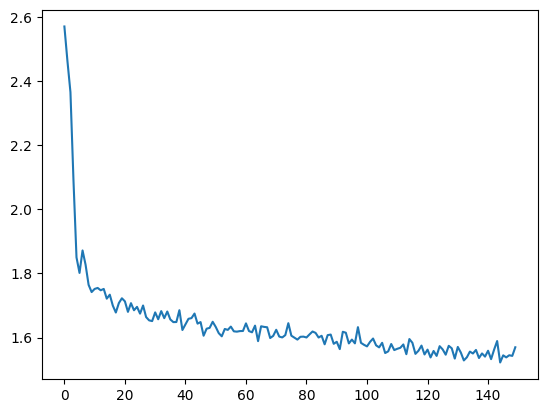

In [ ]:
plt.plot(np.array(losses))

Learned posterior

In [ ]:
use_sampling = False

In [ ]:
# embeddings
gX = g(Xs)
gXstar = g(new_Xs)

posterior_mus, posterior_sigmas =  get_phi(h, gX, gXstar)

# evaluate uncertainty for x*
if use_sampling:
  n_samples_for_avg = 1000
  preds = []
  for i in tqdm(range(n_samples_for_avg)):
    # samples from learned posterior
    epsilon = tf.random.normal(shape=posterior_mus.shape)
    theta_samples =  posterior_mus + epsilon * posterior_sigmas
    # prediction with sampled theta
    fXstar = tf.reduce_sum(theta_samples * gXstar, axis=-1)
    preds.append(fXstar)
  variational_predictions = np.array(preds)
  variational_certainties = np.mean(preds, axis=0)
else:
  variational_predictions = tf.reduce_sum(posterior_mus * gXstar, axis=-1).numpy()
  variational_certainties = variational_predictions

In [ ]:
posterior_var = np.var(variational_predictions, axis=0)
posterior_std = np.sqrt(posterior_var)

In [ ]:
variational_nll, variational_rmse = regression_metrics(new_Ys, variational_certainties)
print("NLL: %.4f, RMSE: %.4f" % (variational_nll, variational_rmse))

NLL: -2.8225, RMSE: 0.7227
